In [3]:
import pandas as pd

import numpy as np

In [4]:
df = pd.read_csv('AI_Impact_on_Jobs_2030.csv')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6           

In [6]:
df.head(10)

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42
5,AI Engineer,92592,11,Master's,0.29,0.51,0.10,Low,0.71,0.79,0.61,0.93,0.65,0.91,0.85,0.45,0.10,0.37
6,Mechanic,107373,23,PhD,0.67,1.09,0.41,Medium,0.56,0.38,0.97,0.85,0.72,0.24,0.26,0.04,0.71,0.11
7,Teacher,53419,12,High School,0.20,1.40,0.17,Low,0.56,0.70,0.14,0.60,0.54,0.20,0.94,0.60,0.69,0.88
8,HR Specialist,139225,12,Master's,0.30,0.61,0.48,Medium,0.22,0.42,0.88,0.32,0.12,0.36,0.91,0.27,0.65,0.00
9,Customer Support,85016,2,High School,0.01,1.01,0.80,High,0.22,0.12,0.34,0.94,0.32,0.52,0.70,0.36,0.97,0.96


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Loading ---
file_path = '/content/AI_Impact_on_Jobs_2030.csv'
df = pd.read_csv(file_path)

print("Original DataFrame head:")
display(df.head())

# --- 2. Feature Engineering: Experience_Level_Group ---
def categorize_experience(years):
    if 1 <= years <= 10:
        return 'Junior'
    elif 11 <= years <= 20:
        return 'Mid-level'
    elif 20 < years <= 30:
        return 'Senior'
    else:
        return 'out of range'

df['Experience_Level_Group'] = df['Years_Experience'].apply(categorize_experience)

# Reorder columns to place Experience_Level_Group after Years_Experience
columns = df.columns.tolist()
columns.remove('Experience_Level_Group')
columns.insert(3, 'Experience_Level_Group') # Insert at index 3, after Years_Experience
df = df[columns]

print("\nDataFrame head after Experience_Level_Group creation:")
display(df.head())

# --- 3. Data Type Conversion: Numerical to float ---
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].astype(float)

print("\nDataFrame info after converting numerical columns to float:")
df.info()

# --- 4. One-Hot Encoding for Categorical Features ---
# Identify categorical columns for one-hot encoding
categorical_features = ['Job_Title', 'Education_Level', 'Experience_Level_Group', 'Risk_Category']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)

print("\nDataFrame head after One-Hot Encoding:")
display(df_encoded.head())

# --- 5. Addressing Data Leakage & Deterministic Link ---
# Define the target columns for Risk_Category and the deterministically linked column
target_risk_columns = ['Risk_Category_Low', 'Risk_Category_Medium', 'Risk_Category_High']
deterministic_feature = 'Automation_Probability_2030'

# Filter out target columns that exist after one-hot encoding
actual_target_columns_in_df = [col for col in target_risk_columns if col in df_encoded.columns]

# Define X by dropping actual target columns and the deterministic feature
X = df_encoded.drop(columns=actual_target_columns_in_df + [deterministic_feature], errors='ignore')

# Redefine y for Risk_Category_Low and Risk_Category_Medium
y_low = df_encoded['Risk_Category_Low']
y_medium = df_encoded['Risk_Category_Medium']

print(f"\nShape of X (features) after removing target columns and '{deterministic_feature}': {X.shape}")
print(f"Shape of y_low (target for Low Risk): {y_low.shape}")
print(f"Shape of y_medium (target for Medium Risk): {y_medium.shape}")

# --- 6. Train-Test Split ---
# Split data into training and testing sets, stratifying by target variables
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(X, y_low, test_size=0.2, random_state=42, stratify=y_low)
X_train_medium, X_test_medium, y_train_medium, y_test_medium = train_test_split(X, y_medium, test_size=0.2, random_state=42, stratify=y_medium)

print("\nShape of training and testing sets:")
print(f"X_train_low: {X_train_low.shape}, X_test_low: {X_test_low.shape}")
print(f"X_train_medium: {X_train_medium.shape}, X_test_medium: {X_test_medium.shape}")

# --- 7. Scaling (Min-Max Normalization) ---
# Identify continuous numerical columns to scale
continuous_numerical_features = [
    'Average_Salary', 'AI_Exposure_Index', 'Tech_Growth_Factor',
    'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6',
    'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10', 'Years_Experience'
]

# Initialize Min-Max scaler
scaler_minmax = MinMaxScaler()

# For Risk_Category_Low model
X_train_low_scaled = X_train_low.copy()
X_test_low_scaled = X_test_low.copy()
X_train_low_scaled[continuous_numerical_features] = scaler_minmax.fit_transform(X_train_low_scaled[continuous_numerical_features])
X_test_low_scaled[continuous_numerical_features] = scaler_minmax.transform(X_test_low_scaled[continuous_numerical_features])

# For Risk_Category_Medium model
X_train_medium_scaled = X_train_medium.copy()
X_test_medium_scaled = X_test_medium.copy()
X_train_medium_scaled[continuous_numerical_features] = scaler_minmax.fit_transform(X_train_medium_scaled[continuous_numerical_features])
X_test_medium_scaled[continuous_numerical_features] = scaler_minmax.transform(X_test_medium_scaled[continuous_numerical_features])

print("\nFirst 5 rows of scaled X_train_low (numerical features):")
display(X_train_low_scaled[continuous_numerical_features].head())

# --- 8. XGBoost Model Training ---
model_low_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model_medium_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

print("\nTraining XGBoost models...")
model_low_xgb.fit(X_train_low_scaled, y_train_low)
print("XGBClassifier for Risk_Category_Low trained.")
model_medium_xgb.fit(X_train_medium_scaled, y_train_medium)
print("XGBClassifier for Risk_Category_Medium trained.")

# --- 9. XGBoost Model Evaluation ---
y_pred_low_xgb = model_low_xgb.predict(X_test_low_scaled)
y_pred_medium_xgb = model_medium_xgb.predict(X_test_medium_scaled)

print("\n--- Evaluation for Risk_Category_Low (XGBoost) ---")
print(f"Accuracy: {accuracy_score(y_test_low, y_pred_low_xgb):.4f}")
print("Classification Report:")
print(classification_report(y_test_low, y_pred_low_xgb))

print("\n--- Evaluation for Risk_Category_Medium (XGBoost) ---")
print(f"Accuracy: {accuracy_score(y_test_medium, y_pred_medium_xgb):.4f}")
print("Classification Report:")
print(classification_report(y_test_medium, y_pred_medium_xgb))

Original DataFrame head:


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42



DataFrame head after Experience_Level_Group creation:


,Job_Title,Average_Salary,Years_Experience,Experience_Level_Group,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Senior,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,Mid-level,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,Junior,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,Mid-level,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,Senior,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42



DataFrame info after converting numerical columns to float:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   float64
 2   Years_Experience             3000 non-null   float64
 3   Experience_Level_Group       3000 non-null   object 
 4   Education_Level              3000 non-null   object 
 5   AI_Exposure_Index            3000 non-null   float64
 6   Tech_Growth_Factor           3000 non-null   float64
 7   Automation_Probability_2030  3000 non-null   float64
 8   Risk_Category                3000 non-null   object 
 9   Skill_1                      3000 non-null   float64
 10  Skill_2                      3000 non-null   float64
 11  Skill_3                      3000 non-null   float64
 12  Skill_4        

...


Training XGBoost models...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier for Risk_Category_Low trained.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier for Risk_Category_Medium trained.

--- Evaluation for Risk_Category_Low (XGBoost) ---
Accuracy: 0.9950
Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      1.00       452
        True       1.00      0.98      0.99       148

    accuracy                           0.99       600
   macro avg       1.00      0.99      0.99       600
weighted avg       1.00      0.99      0.99       600


--- Evaluation for Risk_Category_Medium (XGBoost) ---
Accuracy: 0.9917
Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99       296
        True       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



### Improving Model Accuracy: Hyperparameter Tuning with GridSearchCV

Hyperparameter tuning involves searching for the optimal combination of hyperparameters for your model. `GridSearchCV` systematically works through multiple combinations of parameter tunes, cross-validating each combination to determine which one works best. This often leads to improved model performance.

In [10]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

# Initialize GridSearchCV for the Risk_Category_Low model
grid_search_low = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3, # Using 3-fold cross-validation for demonstration
    verbose=1,
    n_jobs=-1 # Use all available cores
)

print("\nPerforming Grid Search for Risk_Category_Low model...")
grid_search_low.fit(X_train_low_scaled, y_train_low)

print("Best parameters for Risk_Category_Low model:", grid_search_low.best_params_)
print("Best cross-validation accuracy for Risk_Category_Low model:", grid_search_low.best_score_)

# Evaluate the best model on the test set
best_model_low = grid_search_low.best_estimator_
y_pred_low_tuned = best_model_low.predict(X_test_low_scaled)

print("\n--- Evaluation for Tuned Risk_Category_Low (XGBoost) ---")
print(f"Accuracy: {accuracy_score(y_test_low, y_pred_low_tuned):.4f}")
print("Classification Report:")
print(classification_report(y_test_low, y_pred_low_tuned))


Performing Grid Search for Risk_Category_Low model...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Risk_Category_Low model: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best cross-validation accuracy for Risk_Category_Low model: 0.9970833333333333

--- Evaluation for Tuned Risk_Category_Low (XGBoost) ---
Accuracy: 0.9950
Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      1.00       452
        True       1.00      0.98      0.99       148

    accuracy                           0.99       600
   macro avg       1.00      0.99      0.99       600
weighted avg       1.00      0.99      0.99       600



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:40:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Improving Model Latency: Model Persistence (Saving and Loading Models)

Saving your trained models allows you to load them later for predictions without needing to retrain them every time. This significantly reduces the setup time for inference, which is a key factor in improving latency for deployed models. Libraries like `joblib` or `pickle` are commonly used for this.

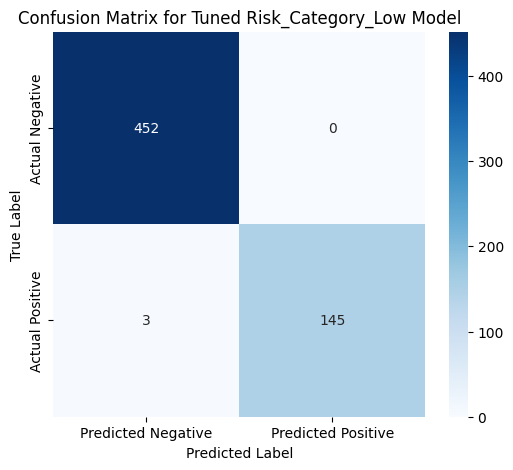

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix for the tuned Risk_Category_Low model
cm_low_tuned = confusion_matrix(y_test_low, y_pred_low_tuned)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_low_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Tuned Risk_Category_Low Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [11]:
import joblib
import os

# Define filenames for saving models
model_low_filename = 'xgb_model_low.joblib'
model_medium_filename = 'xgb_model_medium.joblib'

# Save the trained models
joblib.dump(model_low_xgb, model_low_filename)
joblib.dump(model_medium_xgb, model_medium_filename)

print(f"Model for Risk_Category_Low saved to {model_low_filename}")
print(f"Model for Risk_Category_Medium saved to {model_medium_filename}")

# --- Now, let's simulate loading the models for inference ---
print("\nLoading models for inference...")
loaded_model_low = joblib.load(model_low_filename)
loaded_model_medium = joblib.load(model_medium_filename)

print("Models loaded successfully.")

# Make predictions with the loaded models
loaded_y_pred_low = loaded_model_low.predict(X_test_low_scaled)
loaded_y_pred_medium = loaded_model_medium.predict(X_test_medium_scaled)

print("\nPredictions made with loaded Risk_Category_Low model (first 5):", loaded_y_pred_low[:5])
print("Predictions made with loaded Risk_Category_Medium model (first 5):", loaded_y_pred_medium[:5])

# Verify that predictions are the same as before (optional)
print("\nVerifying loaded model predictions for Risk_Category_Low are identical:",
      np.array_equal(y_pred_low_xgb, loaded_y_pred_low))
print("Verifying loaded model predictions for Risk_Category_Medium are identical:",
      np.array_equal(y_pred_medium_xgb, loaded_y_pred_medium))

Model for Risk_Category_Low saved to xgb_model_low.joblib
Model for Risk_Category_Medium saved to xgb_model_medium.joblib

Loading models for inference...
Models loaded successfully.

Predictions made with loaded Risk_Category_Low model (first 5): [0 0 0 0 1]
Predictions made with loaded Risk_Category_Medium model (first 5): [0 1 1 0 1]

Verifying loaded model predictions for Risk_Category_Low are identical: True
Verifying loaded model predictions for Risk_Category_Medium are identical: True


In [8]:
file_name = "job_risk_prediction.py"
code_to_write = """import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Loading ---
file_path = '/content/AI_Impact_on_Jobs_2030.csv'
df = pd.read_csv(file_path)

print("Original DataFrame head:")
print(df.head())

# --- 2. Feature Engineering: Experience_Level_Group ---
def categorize_experience(years):
    if 1 <= years <= 10:
        return 'Junior'
    elif 11 <= years <= 20:
        return 'Mid-level'
    elif 20 < years <= 30:
        return 'Senior'
    else:
        return 'out of range'

df['Experience_Level_Group'] = df['Years_Experience'].apply(categorize_experience)

# Reorder columns to place Experience_Level_Group after Years_Experience
columns = df.columns.tolist()
columns.remove('Experience_Level_Group')
columns.insert(3, 'Experience_Level_Group') # Insert at index 3, after Years_Experience
df = df[columns]

print("\nDataFrame head after Experience_Level_Group creation:")
print(df.head())

# --- 3. Data Type Conversion: Numerical to float ---
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].astype(float)

print("\nDataFrame info after converting numerical columns to float:")
df.info()

# --- 4. One-Hot Encoding for Categorical Features ---
# Identify categorical columns for one-hot encoding
categorical_features = ['Job_Title', 'Education_Level', 'Experience_Level_Group', 'Risk_Category']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)

print("\nDataFrame head after One-Hot Encoding:")
print(df_encoded.head())

# --- 5. Addressing Data Leakage & Deterministic Link ---
# Define the target columns for Risk_Category and the deterministically linked column
target_risk_columns = ['Risk_Category_Low', 'Risk_Category_Medium', 'Risk_Category_High']
deterministic_feature = 'Automation_Probability_2030'

# Filter out target columns that exist after one-hot encoding
actual_target_columns_in_df = [col for col in target_risk_columns if col in df_encoded.columns]

# Define X by dropping actual target columns and the deterministic feature
X = df_encoded.drop(columns=actual_target_columns_in_df + [deterministic_feature], errors='ignore')

# Redefine y for Risk_Category_Low and Risk_Category_Medium
y_low = df_encoded['Risk_Category_Low']
y_medium = df_encoded['Risk_Category_Medium']

print(f"\nShape of X (features) after removing target columns and '{deterministic_feature}': {X.shape}")
print(f"Shape of y_low (target for Low Risk): {y_low.shape}")
print(f"Shape of y_medium (target for Medium Risk): {y_medium.shape}")

# --- 6. Train-Test Split ---
# Split data into training and testing sets, stratifying by target variables
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(X, y_low, test_size=0.2, random_state=42, stratify=y_low)
X_train_medium, X_test_medium, y_train_medium, y_test_medium = train_test_split(X, y_medium, test_size=0.2, random_state=42, stratify=y_medium)

print("\nShape of training and testing sets:")
print(f"X_train_low: {X_train_low.shape}, X_test_low: {X_test_low.shape}")
print(f"X_train_medium: {X_train_medium.shape}, X_test_medium: {X_test_medium.shape}")

# --- 7. Scaling (Standardization) ---
# Identify continuous numerical columns to scale
continuous_numerical_features = [
    'Average_Salary', 'AI_Exposure_Index', 'Tech_Growth_Factor',
    'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6',
    'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10', 'Years_Experience'
]

# Initialize scaler
scaler_standard = StandardScaler()

# For Risk_Category_Low model
X_train_low_scaled = X_train_low.copy()
X_test_low_scaled = X_test_low.copy()
X_train_low_scaled[continuous_numerical_features] = scaler_standard.fit_transform(X_train_low_scaled[continuous_numerical_features])
X_test_low_scaled[continuous_numerical_features] = scaler_standard.transform(X_test_low_scaled[continuous_numerical_features])

# For Risk_Category_Medium model
X_train_medium_scaled = X_train_medium.copy()
X_test_medium_scaled = X_test_medium.copy()
X_train_medium_scaled[continuous_numerical_features] = scaler_standard.fit_transform(X_train_medium_scaled[continuous_numerical_features])
X_test_medium_scaled[continuous_numerical_features] = scaler_standard.transform(X_test_medium_scaled[continuous_numerical_features])

print("\nFirst 5 rows of scaled X_train_low (numerical features):")
print(X_train_low_scaled[continuous_numerical_features].head())

# --- 8. XGBoost Model Training ---
model_low_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model_medium_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

print("\nTraining XGBoost models...")
model_low_xgb.fit(X_train_low_scaled, y_train_low)
print("XGBClassifier for Risk_Category_Low trained.")
model_medium_xgb.fit(X_train_medium_scaled, y_train_medium)
print("XGBClassifier for Risk_Category_Medium trained.")

# --- 9. XGBoost Model Evaluation ---
y_pred_low_xgb = model_low_xgb.predict(X_test_low_scaled)
y_pred_medium_xgb = model_medium_xgb.predict(X_test_medium_scaled)

print("\n--- Evaluation for Risk_Category_Low (XGBoost) ---")
print(f"Accuracy: {accuracy_score(y_test_low, y_pred_low_xgb):.4f}")
print("Classification Report:")
print(classification_report(y_test_low, y_pred_low_xgb))

print("\n--- Evaluation for Risk_Category_Medium (XGBoost) ---")
print(f"Accuracy: {accuracy_score(y_test_medium, y_pred_medium_xgb):.4f}")
print("Classification Report:")
print(classification_report(y_test_medium, y_pred_medium_xgb))
"""

with open(file_name, 'w') as f:
    f.write(code_to_write)
print(f"Code from cell deedcc77 saved to {file_name}")

Code from cell deedcc77 saved to job_risk_prediction.py
